In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# df_stn: [2024-07-01 00:00:00 ~ 2025-06-30 23:00:00]
df_stn = pd.read_csv('Sikorsky_data.csv')
df_stn['TmStamp'] = pd.to_datetime(df_stn['TmStamp'], format='mixed')
df_stn = df_stn[df_stn['TmStamp'] > pd.to_datetime('2024-06-30 23:59:00')]

# Add east and north components
alpha = -13
df_stn['rad'] = np.pi/180 * ((alpha + 630 - df_stn['WDIR']) % 360)
df_stn['u_e'] = df_stn['WSPD'] * np.cos(df_stn['rad'])
df_stn['u_n'] = df_stn['WSPD'] * np.sin(df_stn['rad'])

# df_fcst: [2024-07-01 00:00:00 ~ 2025-06-30 23:00:00]
df_fcst = pd.read_csv('Sikorsky_fcst.csv')
df_fcst['TmStamp'] = pd.to_datetime(df_fcst['TmStamp'], format='mixed')

In [2]:
# Compute u_e error and stats
u_e_err = df_fcst['u_e'].values - df_stn['u_e'].values
print(f'Mean u_e error: {np.mean(u_e_err):.3f}')
print(f'Standard deviation of u_e error: {np.std(u_e_err, ddof=1):.3f}')

# Compute u_n error and stats
u_n_err = df_fcst['u_n'].values - df_stn['u_n'].values
print(f'Mean u_n error: {np.mean(u_n_err):.3f}')
print(f'Standard deviation of u_n error: {np.std(u_n_err, ddof=1):.3f}')

# Compute correlation coefficient (rho) of forecast errors
rho = np.corrcoef(u_e_err, u_n_err)[0, 1]
print(f'Estimated rho: {rho:.3f}')

Mean u_e error: 0.506
Standard deviation of u_e error: 1.771
Mean u_n error: 0.048
Standard deviation of u_n error: 1.962
Estimated rho: 0.054


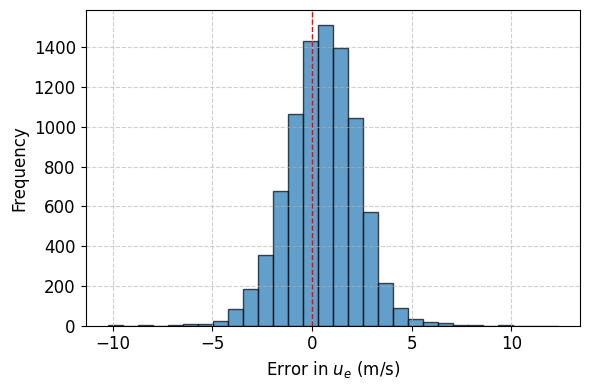

In [3]:
# u_e error distribution
plt.figure(figsize=(6, 4))
plt.hist(u_e_err, bins=30, color='#1f77b4', edgecolor='k', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel(r'Error in $u_e$ (m/s)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

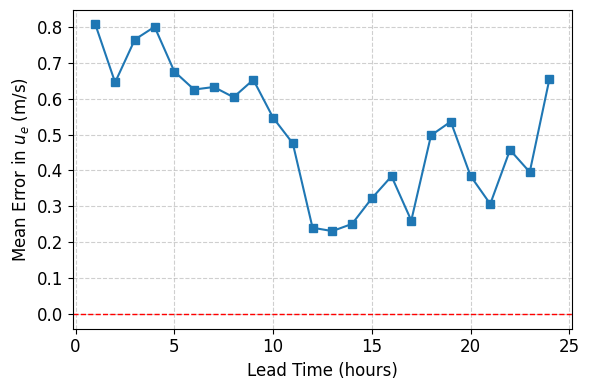

In [4]:
# Reshape into (365 days, 24 hours)
u_e_err_reshaped = u_e_err.reshape(365, 24)

# Mean error at each lead time (average over 365 days)
u_e_err_lead = u_e_err_reshaped.mean(axis=0)

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, 25), u_e_err_lead, color='#1f77b4', marker='s')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Lead Time (hours)', fontsize=12)
plt.ylabel(r'Mean Error in $u_e$ (m/s)', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

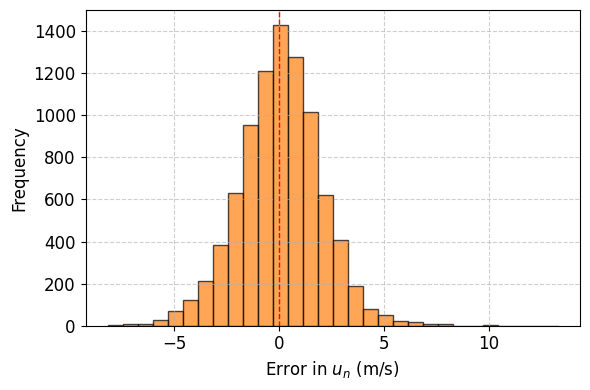

In [5]:
# u_n error distribution
plt.figure(figsize=(6, 4))
plt.hist(u_n_err, bins=30, color='#ff7f0e', edgecolor='k', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel(r'Error in $u_n$ (m/s)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

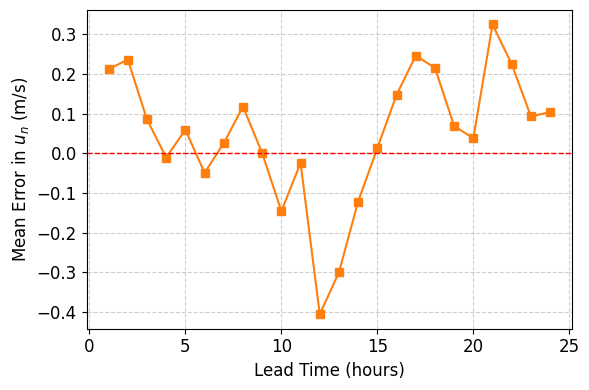

In [6]:
# Reshape into (365 days, 24 hours)
u_n_err_reshaped = u_n_err.reshape(365, 24)

# Mean error at each lead time (average over 365 days)
u_n_err_lead = u_n_err_reshaped.mean(axis=0)

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, 25), u_n_err_lead, color='#ff7f0e', marker='s')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Lead Time (hours)', fontsize=12)
plt.ylabel(r'Mean Error in $u_n$ (m/s)', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()